# 5 — Análise Estatística

**Pré-requisito:** `data/processed/results.pkl` gerado pelo notebook 4.

**Saídas:** `figures/nemenyi_heatmap.png`, `figures/accuracy_boxplot.png`

In [1]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    import scikit_posthocs as sp
    HAS_SP = True
except ImportError:
    print('AVISO: pip install scikit-posthocs')
    HAS_SP = False

warnings.filterwarnings('ignore')

ALPHA        = 0.05
ROOT_DIR     = Path('.')
FIGURES_DIR  = ROOT_DIR / 'figures'
RESULTS_PATH = ROOT_DIR / 'data' / 'processed' / 'results.pkl'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_PATH, 'rb') as f:
    saved      = pickle.load(f)
results    = saved['results']
all_labels = saved['all_labels']

model_names = list(results.keys())
print(f'Modelos carregados: {model_names}')

Modelos carregados: ['Árvore de Decisão', 'Floresta Aleatória', 'SVM', 'KNN', 'MLP']


## Teste de Friedman

In [2]:
acc_matrix = np.array([results[n]['accuracy'] for n in model_names])

stat, p_value = stats.friedmanchisquare(*acc_matrix)
print(f'Teste de Friedman')
print(f'  chi2 = {stat:.4f}')
print(f'  p    = {p_value:.4f}')

if p_value < ALPHA:
    print(f'\n→ Rejeita H0 (p < {ALPHA}): diferença significativa entre modelos.')
else:
    print(f'\n→ Não rejeita H0 (p >= {ALPHA}): sem diferença significativa.')

Teste de Friedman
  chi2 = 12.8989
  p    = 0.0118

→ Rejeita H0 (p < 0.05): diferença significativa entre modelos.


## Post-hoc de Nemenyi

p-valores de Nemenyi:


,Árvore de Decisão,Floresta Aleatória,SVM,KNN,MLP
Árvore de Decisão,1.0000,0.9307,0.9751,0.1448,0.9874
Floresta Aleatória,0.9307,1.0000,0.6277,0.5624,0.6912
SVM,0.9751,0.6277,1.0000,0.0306,1.0000
KNN,0.1448,0.5624,0.0306,1.0000,0.0409
MLP,0.9874,0.6912,1.0000,0.0409,1.0000


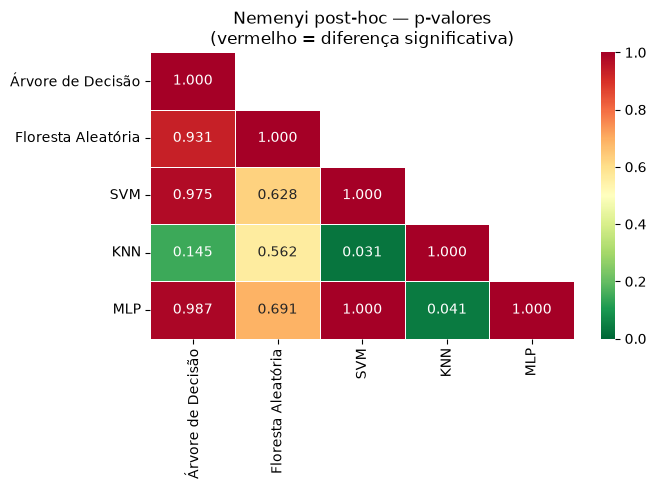

In [3]:
if p_value < ALPHA:
    if HAS_SP:
        acc_df  = pd.DataFrame(acc_matrix.T, columns=model_names)
        nemenyi = sp.posthoc_nemenyi_friedman(acc_df)

        print('p-valores de Nemenyi:')
        display(nemenyi.round(4))

        fig, ax = plt.subplots(figsize=(7, 5))
        mask = np.triu(np.ones_like(nemenyi, dtype=bool), k=1)
        sns.heatmap(nemenyi, mask=mask, annot=True, fmt='.3f',
                    cmap='RdYlGn_r', vmin=0, vmax=1, linewidths=0.5, ax=ax,
                    xticklabels=model_names, yticklabels=model_names)
        ax.set_title('Nemenyi post-hoc — p-valores\n(vermelho = diferença significativa)')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'nemenyi_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Instale scikit-posthocs: python -m pip install scikit-posthocs')
else:
    print('Friedman não rejeitou H0 — post-hoc não aplicável.')

## Boxplot de Acurácia

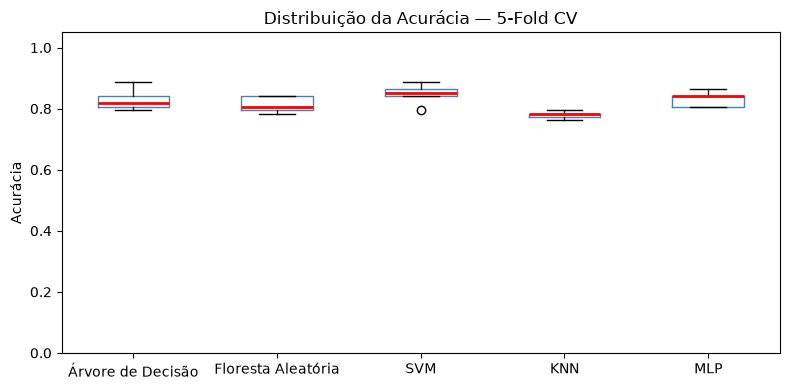

In [4]:
acc_box = pd.DataFrame({n: results[n]['accuracy'] for n in model_names})

fig, ax = plt.subplots(figsize=(8, 4))
acc_box.boxplot(ax=ax, grid=False,
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Acurácia')
ax.set_title('Distribuição da Acurácia — 5-Fold CV')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()